In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Data/clean_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (16266, 54)


,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_level,weak_foot,skill_moves,...,defending_standing_tackle,defending_sliding_tackle,years_at_club,contract_years_remaining,is_loaned,nationality_freq,league_freq,preferred_foot_Right,position_group_DEF,position_group_MID
0,90,94,174500000,320000,22,186,75,1.0,4,4,...,79,77,2.221918,4.0,0,1329,488,True,False,True
1,89,90,120500000,340000,26,182,74,1.0,4,3,...,87,86,9.167123,4.0,0,227,488,True,False,True
2,89,89,86000000,140000,30,177,75,1.0,4,3,...,86,85,10.227397,4.0,0,996,762,True,False,True
3,89,90,111000000,170000,26,181,73,1.0,4,4,...,85,79,4.208219,4.0,0,131,431,True,True,False
4,87,87,79500000,69000,28,175,68,1.0,4,3,...,85,80,5.052055,4.0,0,558,607,True,False,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16266 entries, 0 to 16265
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   overall                      16266 non-null  int64  
 1   potential                    16266 non-null  int64  
 2   value_eur                    16266 non-null  int64  
 3   wage_eur                     16266 non-null  int64  
 4   age                          16266 non-null  int64  
 5   height_cm                    16266 non-null  int64  
 6   weight_kg                    16266 non-null  int64  
 7   league_level                 16266 non-null  float64
 8   weak_foot                    16266 non-null  int64  
 9   skill_moves                  16266 non-null  int64  
 10  international_reputation     16266 non-null  int64  
 11  pace                         16266 non-null  float64
 12  shooting                     16266 non-null  float64
 13  passing                    

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
overall,16266.0,6.593932e+01,6.864922e+00,47.000000,62.000000,6.600000e+01,7.000000e+01,9.100000e+01
potential,16266.0,7.135553e+01,6.353047e+00,49.000000,67.000000,7.100000e+01,7.600000e+01,9.500000e+01
value_eur,16266.0,3.086757e+06,8.216863e+06,0.000000,525000.000000,1.100000e+06,2.200000e+06,1.745000e+08
wage_eur,16266.0,1.069216e+04,2.081215e+04,500.000000,1000.000000,4.000000e+03,1.100000e+04,6.100000e+05
age,16266.0,2.507414e+01,4.648946e+00,16.000000,21.000000,2.500000e+01,2.800000e+01,4.400000e+01
height_cm,16266.0,1.810918e+02,6.568978e+00,155.000000,176.000000,1.810000e+02,1.860000e+02,2.060000e+02
weight_kg,16266.0,7.436198e+01,6.585766e+00,47.000000,70.000000,7.400000e+01,7.900000e+01,1.040000e+02
league_level,16266.0,1.400221e+00,7.690029e-01,1.000000,1.000000,1.000000e+00,2.000000e+00,4.000000e+00
weak_foot,16266.0,2.985061e+00,6.464626e-01,1.000000,3.000000,3.000000e+00,3.000000e+00,5.000000e+00
skill_moves,16266.0,2.529386e+00,6.316021e-01,2.000000,2.000000,2.000000e+00,3.000000e+00,5.000000e+00


## 2. توزيع أهم المتغيرات

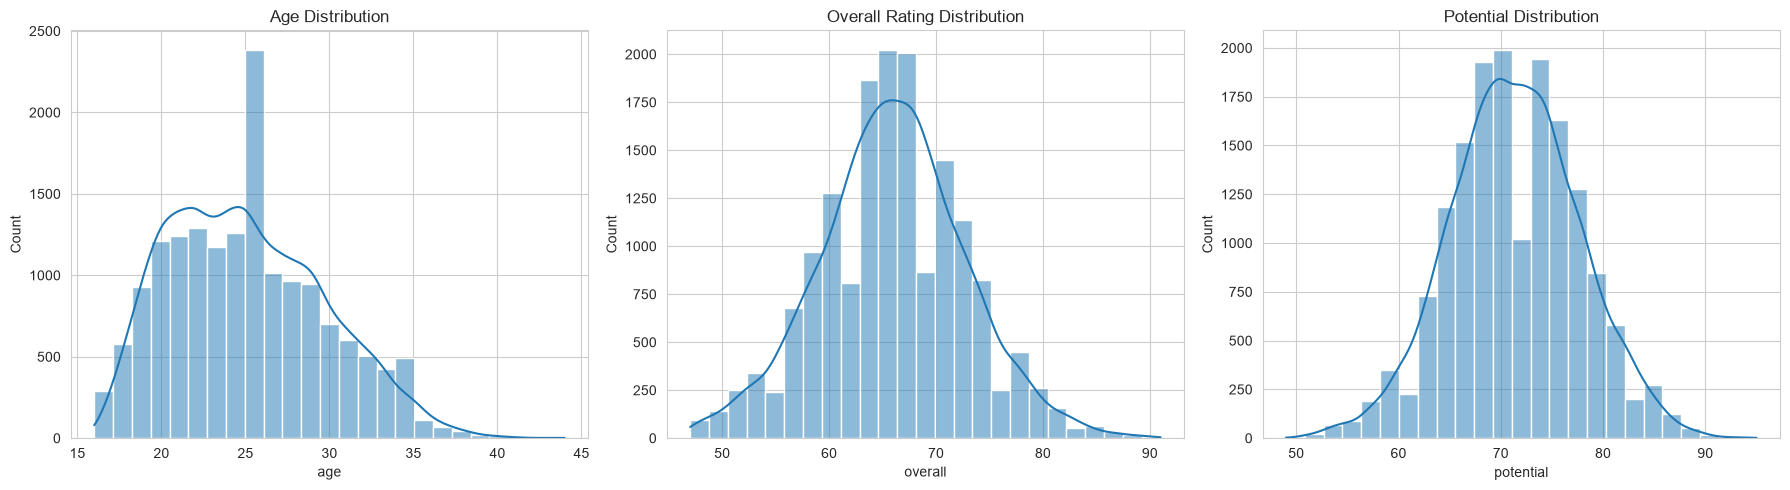

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], bins=25, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['overall'], bins=25, kde=True, ax=axes[1])
axes[1].set_title('Overall Rating Distribution')

sns.histplot(df['potential'], bins=25, kde=True, ax=axes[2])
axes[2].set_title('Potential Distribution')

plt.tight_layout()
plt.show()

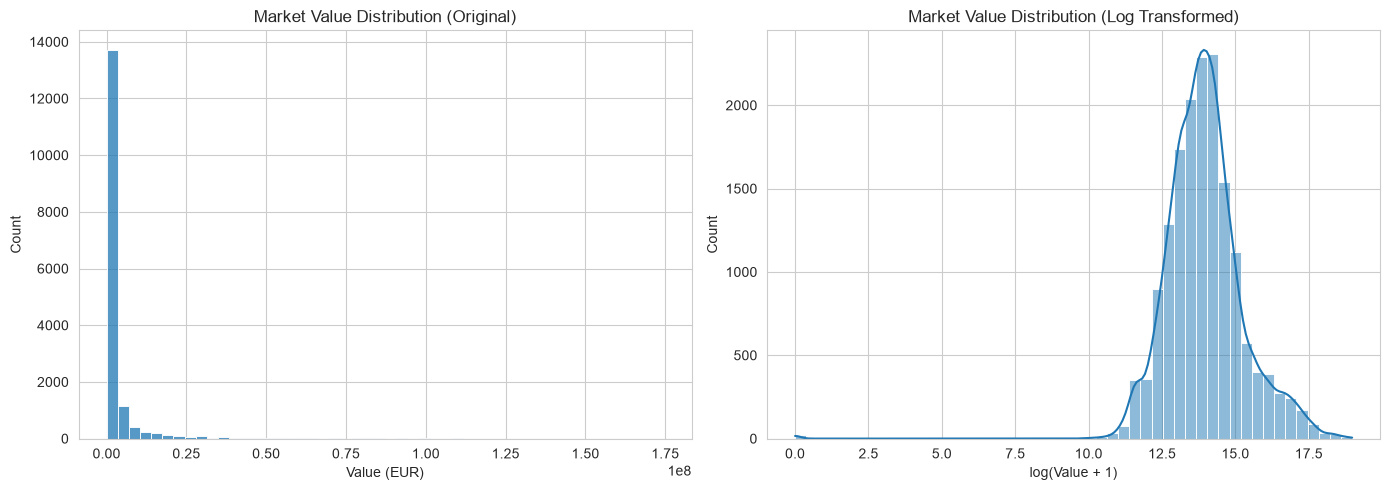

Skewness (Original): 8.49
Skewness (Log Transformed): -0.93


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['value_eur'], bins=50, ax=axes[0])
axes[0].set_title('Market Value Distribution (Original)')
axes[0].set_xlabel('Value (EUR)')

sns.histplot(np.log1p(df['value_eur']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Market Value Distribution (Log Transformed)')
axes[1].set_xlabel('log(Value + 1)')

plt.tight_layout()
plt.show()

print(f"Skewness (Original): {df['value_eur'].skew():.2f}")
print(f"Skewness (Log Transformed): {np.log1p(df['value_eur']).skew():.2f}")

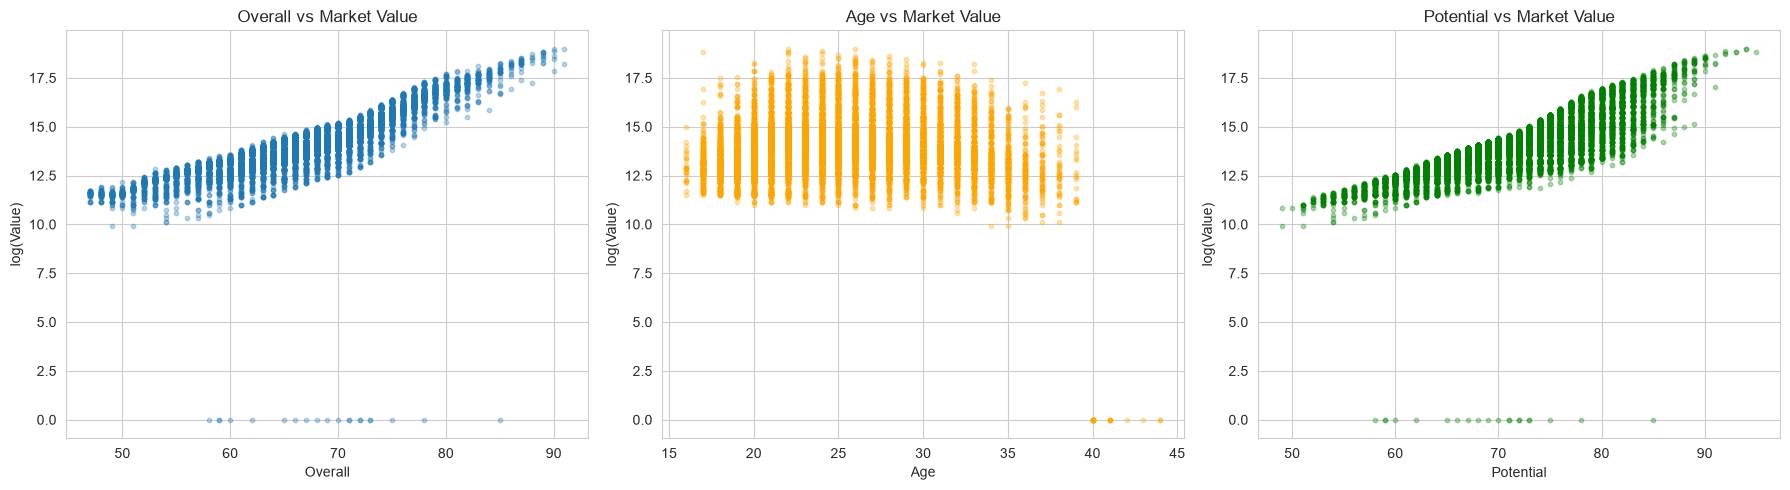

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['overall'], np.log1p(df['value_eur']), alpha=0.3, s=10)
axes[0].set_xlabel('Overall'); axes[0].set_ylabel('log(Value)')
axes[0].set_title('Overall vs Market Value')

axes[1].scatter(df['age'], np.log1p(df['value_eur']), alpha=0.3, s=10, color='orange')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('log(Value)')
axes[1].set_title('Age vs Market Value')

axes[2].scatter(df['potential'], np.log1p(df['value_eur']), alpha=0.3, s=10, color='green')
axes[2].set_xlabel('Potential'); axes[2].set_ylabel('log(Value)')
axes[2].set_title('Potential vs Market Value')

plt.tight_layout()
plt.show()

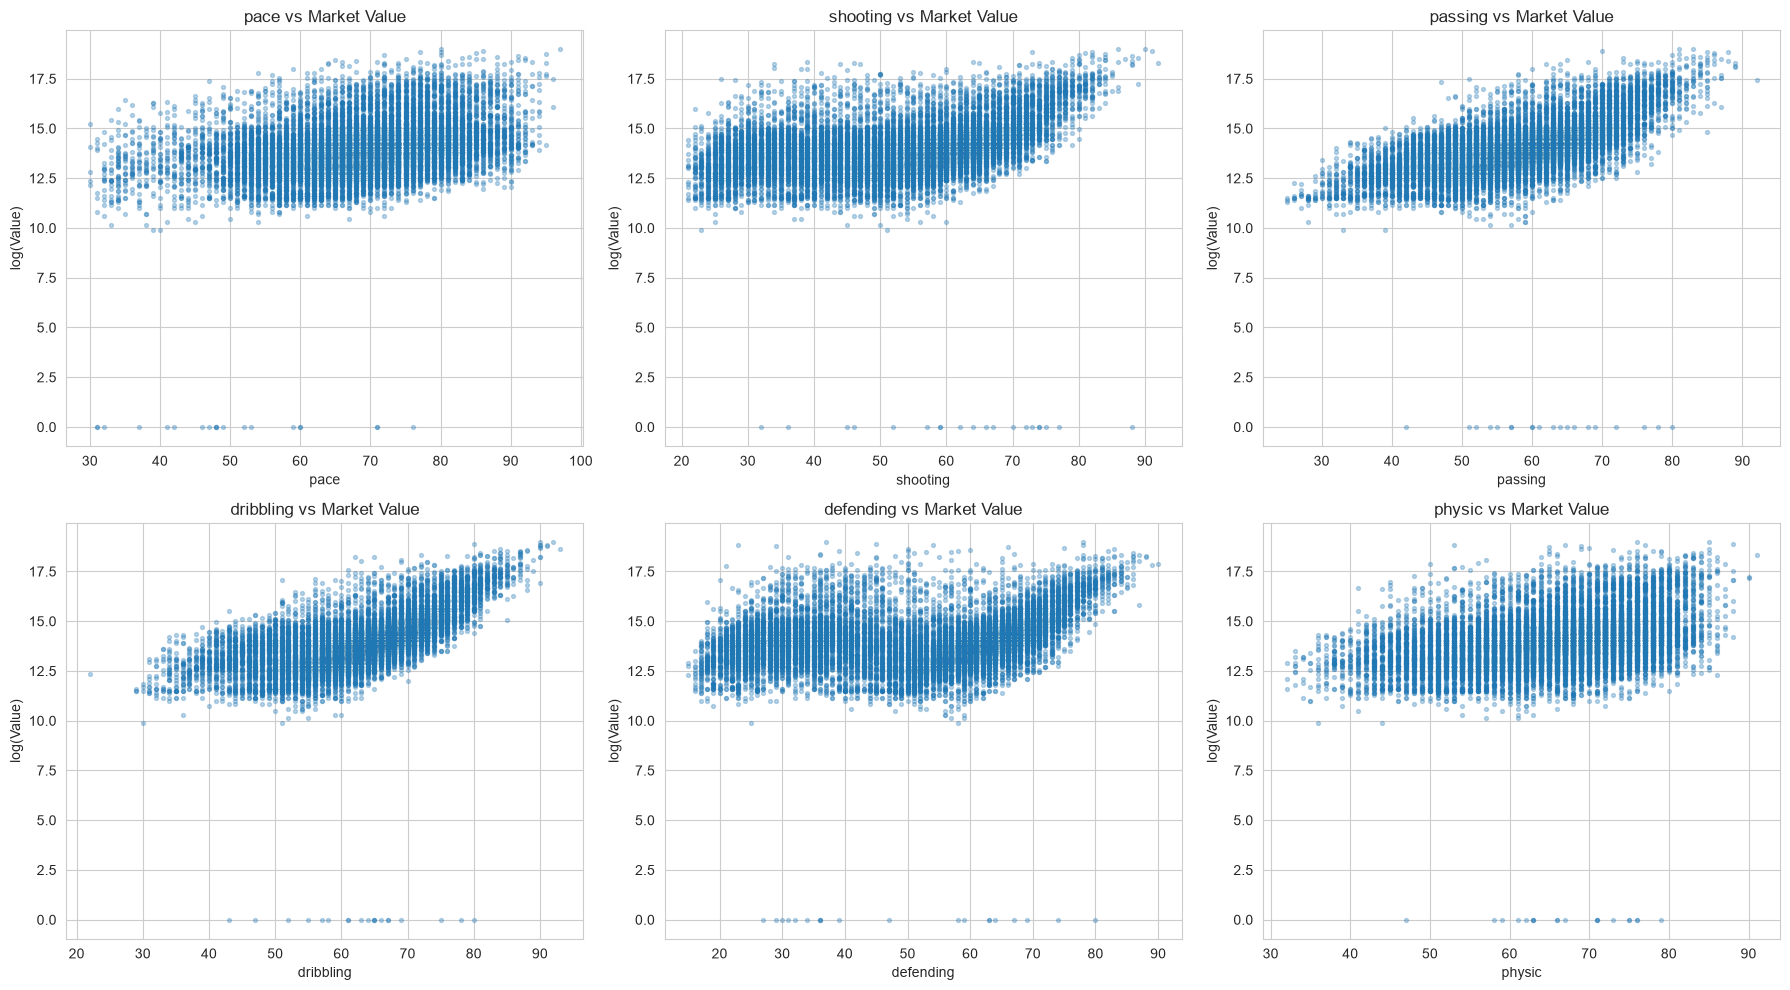

In [9]:
main_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, stat in enumerate(main_stats):
    axes[i].scatter(df[stat], np.log1p(df['value_eur']), alpha=0.3, s=8)
    axes[i].set_xlabel(stat)
    axes[i].set_ylabel('log(Value)')
    axes[i].set_title(f'{stat} vs Market Value')

plt.tight_layout()
plt.show()

In [10]:
correlation_with_value = (
    df.corr(numeric_only=True)['value_eur']
    .drop('value_eur')
    .sort_values(ascending=False)
)

print("Top 10 Features Positively Correlated with Market Value:")
display(correlation_with_value.head(10))

print("\nTop 5 Features Negatively (or least) Correlated with Market Value:")
display(correlation_with_value.tail(5))

Top 10 Features Positively Correlated with Market Value:


wage_eur                    0.830182
international_reputation    0.737725
overall                     0.556380
movement_reactions          0.513676
potential                   0.504324
mentality_composure         0.454029
skill_ball_control          0.447631
attacking_short_passing     0.443063
dribbling                   0.412933
passing                     0.411768
Name: value_eur, dtype: float64


Top 5 Features Negatively (or least) Correlated with Market Value:


league_freq             0.002774
is_loaned              -0.010678
preferred_foot_Right   -0.023559
position_group_DEF     -0.044112
league_level           -0.132360
Name: value_eur, dtype: float64

C:\Users\ENG_ALI_WENINY\AppData\Local\Temp\ipykernel_35124\3113017119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


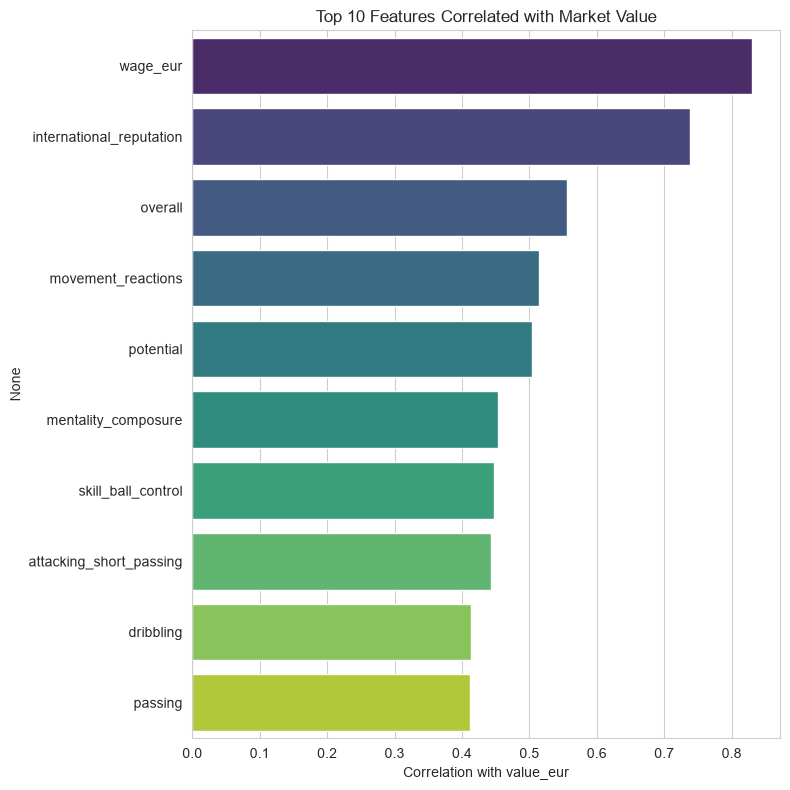

In [11]:
plt.figure(figsize=(8, 8))
top_corr = correlation_with_value.head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title('Top 10 Features Correlated with Market Value')
plt.xlabel('Correlation with value_eur')
plt.tight_layout()
plt.show()

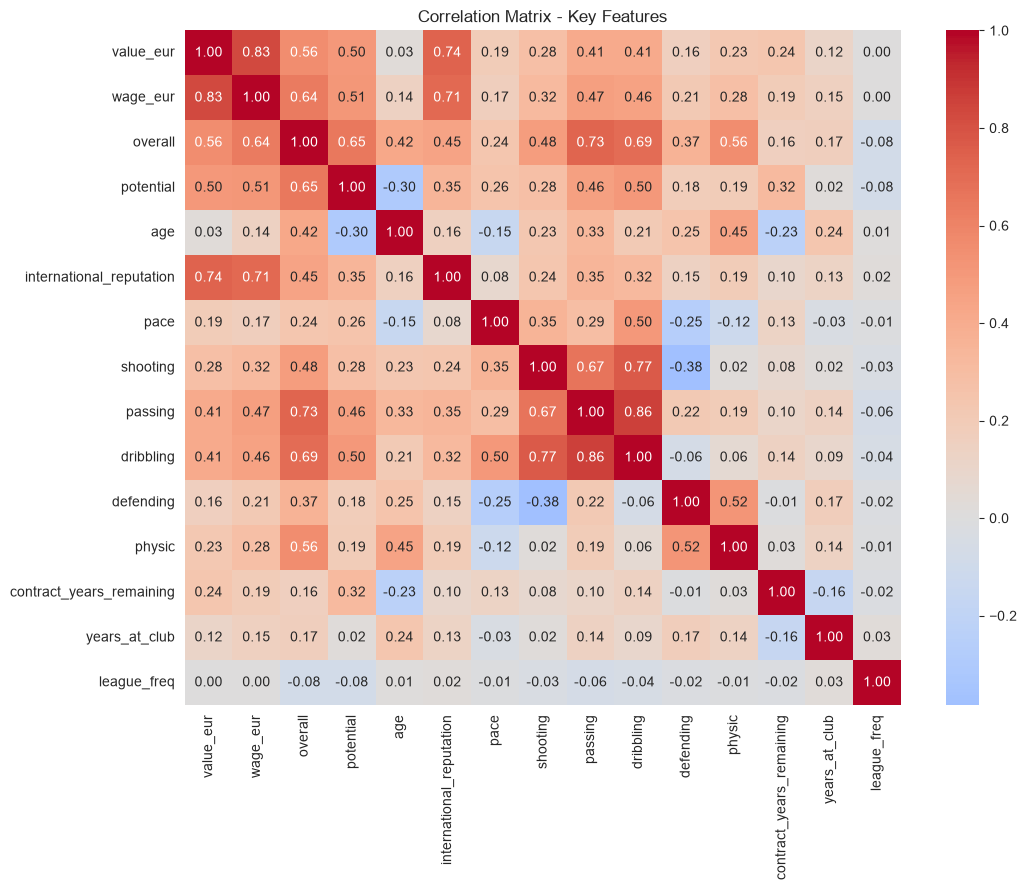

In [12]:
key_features = ['value_eur', 'wage_eur', 'overall', 'potential', 'age',
                 'international_reputation', 'pace', 'shooting', 'passing',
                 'dribbling', 'defending', 'physic', 'contract_years_remaining',
                 'years_at_club', 'league_freq']

corr_matrix = df[key_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Features')
plt.tight_layout()
plt.show()

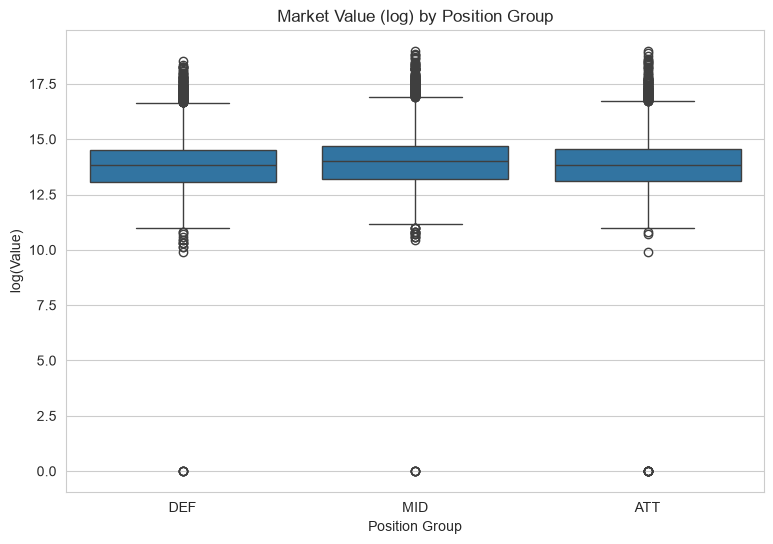

position_group_label
MID    1200000.0
ATT    1000000.0
DEF    1000000.0
Name: value_eur, dtype: float64


In [13]:
df_plot = df.copy()
df_plot['position_group_label'] = 'ATT'  # القيمة المرجعية (baseline) اللي اتشالت وقت الـ drop_first
df_plot.loc[df_plot['position_group_DEF'] == True, 'position_group_label'] = 'DEF'
df_plot.loc[df_plot['position_group_MID'] == True, 'position_group_label'] = 'MID'

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_plot, x='position_group_label', y=np.log1p(df_plot['value_eur']),
            order=['DEF', 'MID', 'ATT'])
plt.title('Market Value (log) by Position Group')
plt.xlabel('Position Group')
plt.ylabel('log(Value)')
plt.show()

print(df_plot.groupby('position_group_label')['value_eur'].median().sort_values(ascending=False))

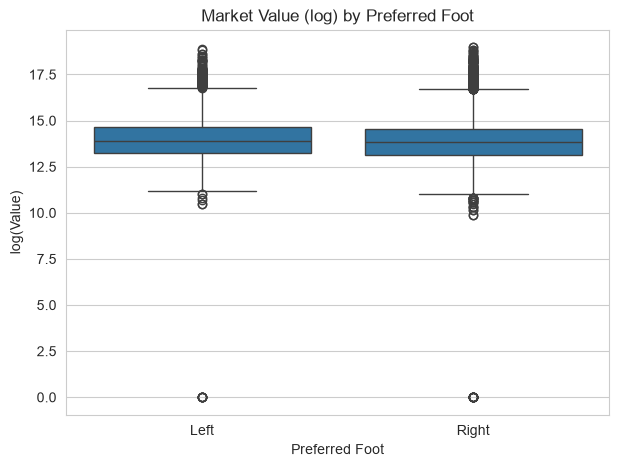

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='preferred_foot_Right', y=np.log1p(df['value_eur']))
plt.xticks([0, 1], ['Left', 'Right'])
plt.title('Market Value (log) by Preferred Foot')
plt.xlabel('Preferred Foot')
plt.ylabel('log(Value)')
plt.show()